<a href="https://colab.research.google.com/github/BrunoOrnll/Gitlab/blob/main/git_tab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/usr/local/lib/python3.12/dist-packages/openpyxl/packaging/custom.py:213: UserWarning: Unknown type for ESRI_WORKBOOK_ID
  warn(f"Unknown type for {prop.name}")
/usr/local/lib/python3.12/dist-packages/openpyxl/packaging/custom.py:213: UserWarning: Unknown type for ESRI_WORKBOOK_ID
  warn(f"Unknown type for {prop.name}")



=== 1) ESTRUTURA E QUALIDADE DOS DADOS (SLIDE 5) ===
Linhas: 23 | Colunas: 4
root
 |-- Ano: double (nullable = true)
 |-- Obitos: double (nullable = true)
 |-- Populacao: double (nullable = true)
 |-- Taxa: double (nullable = true)


=== ESTATÍSTICAS (MÉDIA, DESVIO, MÍN, MÁX) ===
+-------+------------------+------------------+
|summary|            Obitos|         Populacao|
+-------+------------------+------------------+
|  count|                23|                23|
|   mean| 841.6521739130435|6303419.0869565215|
| stddev|158.16378412486105| 280698.9088853873|
|    min|             580.0|         5857904.0|
|    max|            1073.0|         6775561.0|
+-------+------------------+------------------+

=== 4) ANÁLISE DE DADOS DISCREPANTES (OUTLIERS) ===
Critério: Valores fora do intervalo [525.32 a 1157.98]
Nenhum dado discrepante (outlier) detectado detalhadamente.
Resultado: A base de dados apresenta variações dentro da normalidade estatística.


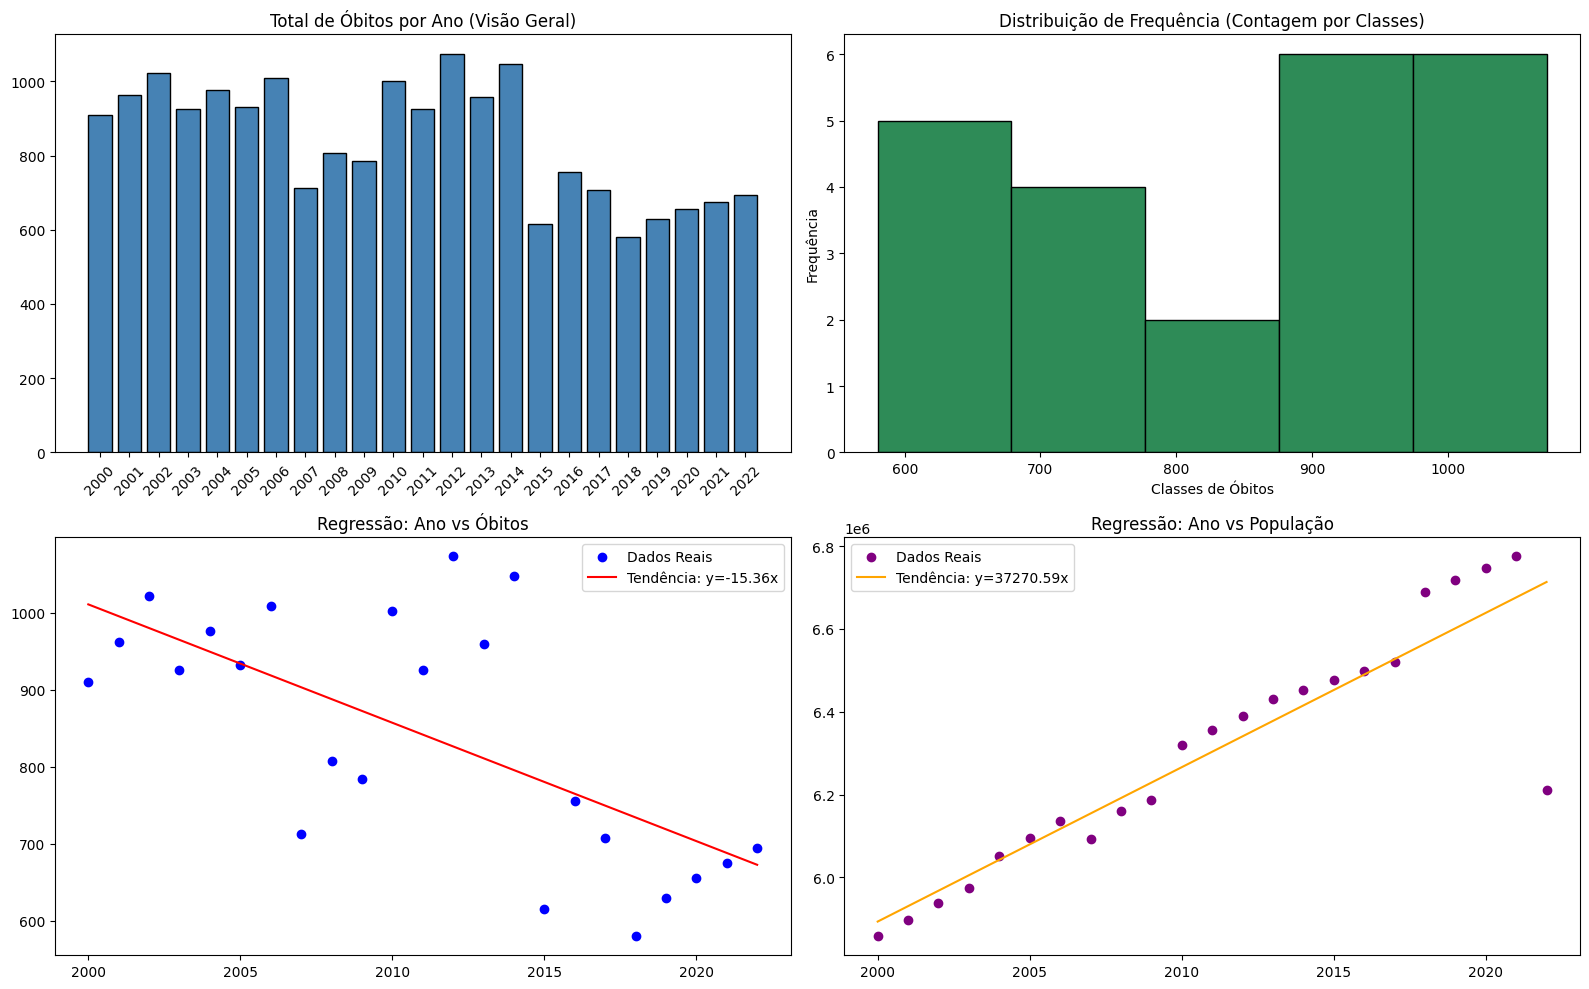

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import unicodedata
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, count, when, mean, stddev, min, max

# Função auxiliar para remover acentos e padronizar nomes
def normalizar_texto(texto):
    if not isinstance(texto, str): #verifica se n é string
        return str(texto) #converte para str
    texto = texto.lower().strip() #minusculo/remove espaço
    return "".join(
        c for c in unicodedata.normalize('NFD', texto)
        if unicodedata.category(c) != 'Mn'
    )

def iniciar_projeto():
    return SparkSession.builder.appName("AnaliseMortalidade").getOrCreate() #Cria uma sessão Spark.

def processar_dados(caminho):
    pdf_bruto = pd.read_excel(caminho) #le e armazena excel em pdf_bruto
    linha_cabecalho = 0
    for i, linha in pdf_bruto.iterrows(): #i = indice da linha, linha = conteudo da linha
        valores = [normalizar_texto(v) for v in linha.values]
        if 'ano' in valores:
            linha_cabecalho = i
            break

    pdf = pd.read_excel(caminho, skiprows=linha_cabecalho + 1)
    if 'Ano' not in pdf.columns:
        pdf.columns = pdf_bruto.iloc[linha_cabecalho].values

    cols_originais = pdf.columns
    mapeamento = {}
    for c in cols_originais:
        norm = normalizar_texto(c) # c = cols_originais "basicamente as colunas"
        if 'ano' in norm: mapeamento['ano'] = c
        elif 'obito' in norm: mapeamento['obitos'] = c
        elif 'popula' in norm: mapeamento['populacao'] = c
        elif 'taxa' in norm: mapeamento['taxa'] = c

    # Qualidade dos dados - Conversão para numérico
    for chave, nome_real in mapeamento.items():
        pdf[nome_real] = pd.to_numeric(pdf[nome_real], errors='coerce')#NaN

    pdf = pdf.dropna(subset=[mapeamento['ano'], mapeamento['obitos']])#limpeza
    pdf = pdf.sort_values(by=mapeamento['ano'])#ordenar

    return pdf.rename(columns={
        mapeamento['ano']: 'Ano',
        mapeamento['obitos']: 'Obitos',
        mapeamento['populacao']: 'Populacao',
        mapeamento['taxa']: 'Taxa'
    })[['Ano', 'Obitos', 'Populacao', 'Taxa']]#tratamento de dados renomeação

def realizar_analise_estatistica(spark, pdf): #Converte Pandas DataFrame em Spark DataFrame.
    df_spark = spark.createDataFrame(pdf) #necessário porque o restante da análise estatística usa funções do PySpark, e elas só funcionam em DataFrames Spark

    print("\n=== 1) ESTRUTURA E QUALIDADE DOS DADOS (SLIDE 5) ===")
    print(f"Linhas: {df_spark.count()} | Colunas: {len(df_spark.columns)}") #quantitade linha/coluna
    df_spark.printSchema() #tipo de coluna

    print("\n=== ESTATÍSTICAS (MÉDIA, DESVIO, MÍN, MÁX) ===")
    df_spark.describe(['Obitos', 'Populacao']).show()  #gera e mostra estatisticas

    # --- 4) IDENTIFICAÇÃO DETALHADA DE OUTLIERS  ---
    stats = df_spark.select(mean("Obitos").alias("m"), stddev("Obitos").alias("s")).collect()[0] #calcula a media (m) e o desvido padrão (s)
    media = stats['m'] #quarda m
    desvio = stats['s'] #quarda s

    # Critério técnico: Média +/- 2 Desvios Padrão
    limite_superior = media + (2 * desvio)
    limite_inferior = media - (2 * desvio)

    print(f"=== 4) ANÁLISE DE DADOS DISCREPANTES (OUTLIERS) ===")
    print(f"Critério: Valores fora do intervalo [{limite_inferior:.2f} a {limite_superior:.2f}]")

    # Busca por valores discrepantes
    outliers = df_spark.filter((col("Obitos") > limite_superior) | (col("Obitos") < limite_inferior)) #filtra valores

    if outliers.count() > 0: #Verifica se existem outliers.
        print(f"DETALHAMENTO DE OUTLIERS ENCONTRADOS ({outliers.count()} registro(s)):")
        outliers.select("Ano", "Obitos", "Populacao").show(truncate=False) #Mostra dados discrepantes (se existir)
        print("Análise: Estes pontos divergem do padrão histórico e devem ser verificados.")
    else:
        print("Nenhum dado discrepante (outlier) detectado detalhadamente.")
        print("Resultado: A base de dados apresenta variações dentro da normalidade estatística.")

    return df_spark #retorna df

def gerar_graficos(pdf):  #criação de graficos/buscar valores
    x = pdf['Ano'].values
    y_obitos = pdf['Obitos'].values
    y_pop = pdf['Populacao'].values

    # Cálculos das Regressões Lineares (m)inclinação(b)intercepto
    m_ob, b_ob = np.polyfit(x, y_obitos, 1)
    m_pop, b_pop = np.polyfit(x, y_pop, 1)

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))#4 graficos

    # [0,0] Gráfico de Barras Original
    axes[0,0].bar(x.astype(int).astype(str), y_obitos, color='steelblue', edgecolor='black') #Cria gráfico de barras dos óbitos por ano.
    axes[0,0].set_title('Total de Óbitos por Ano (Visão Geral)')
    axes[0,0].tick_params(axis='x', rotation=45)

    # [0,1] 3) Distribuição de Frequência
    axes[0,1].hist(y_obitos, bins=5, color='seagreen', edgecolor='black') #Cria distribuição de frequência. (contagem total por obito)
    axes[0,1].set_title('Distribuição de Frequência (Contagem por Classes)')
    axes[0,1].set_xlabel('Classes de Óbitos')
    axes[0,1].set_ylabel('Frequência')

    # [1,0] 2) Regressão Linear: Ano vs Óbitos
    axes[1,0].scatter(x, y_obitos, color='blue', label='Dados Reais')
    axes[1,0].plot(x, m_ob*x + b_ob, color='red', label=f'Tendência: y={m_ob:.2f}x')
    axes[1,0].set_title('Regressão: Ano vs Óbitos')
    axes[1,0].legend()

    # [1,1] Regressão Linear: Ano vs População
    axes[1,1].scatter(x, y_pop, color='purple', label='Dados Reais') #Mostra pontos reais.
    axes[1,1].plot(x, m_pop*x + b_pop, color='orange', label=f'Tendência: y={m_pop:.2f}x') #Desenha linha de tendência.
    axes[1,1].set_title('Regressão: Ano vs População')
    axes[1,1].legend()

    plt.tight_layout() #organização de espaçamento
    plt.show() #exibir graficos

# EXECUÇÃO PRINCIPAL
try:
    sessao = iniciar_projeto()
    caminho = "https://raw.githubusercontent.com/BrunoOrnll/Gitlab/main/dados_transito.xlsx" #URL excel github

    df_limpo = processar_dados(caminho) #Processa e limpa dados.
    realizar_analise_estatistica(sessao, df_limpo) #Executa análise estatística.
    gerar_graficos(df_limpo) #Gera gráficos.

finally: #Executa mesmo se ocorrer erro.
    if 'sessao' in locals(): #Verifica se sessão existe.
        sessao.stop() #Fecha sessão Spark.